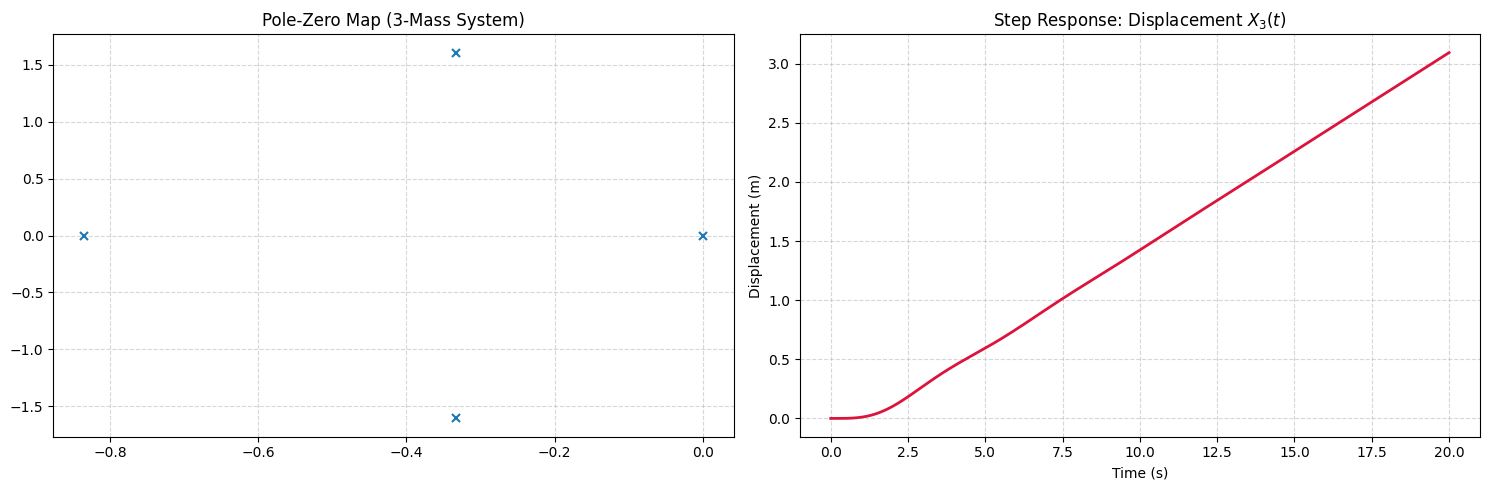

System Poles: [-0.33251681+1.60752974j -0.33251681-1.60752974j -0.83496638+0.j
  0.        +0.j        ]
------------------------------
Result: System is Marginally Stable (contains an integrator).
Observation: The mass will continue to move (drift) under constant force.


In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# Define the Transfer Function H(s) = X3(s) / F(s)
# Numerator: 3
# Denominator: 8s^4 + 12s^3 + 26s^2 + 18s
num = [3]
den = [8, 12, 26, 18, 0]

sys = ct.TransferFunction(num, den)

# Create plotting environment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Pole-Zero Map
ct.pole_zero_plot(sys, ax=ax1)
ax1.set_title('Pole-Zero Map (3-Mass System)')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Step Response
# We simulate for 20 seconds to see the displacement trend
t = np.linspace(0, 20, 1000)
t, y = ct.step_response(sys, t)

ax2.plot(t, y, lw=2, color='crimson')
ax2.set_title('Step Response: Displacement $X_3(t)$')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Displacement (m)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Quick Stability Analysis
poles = ct.poles(sys)
print(f"System Poles: {poles}")
print("-" * 30)
if any(np.real(poles) == 0):
    print("Result: System is Marginally Stable (contains an integrator).")
    print("Observation: The mass will continue to move (drift) under constant force.")